# Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

# Loading Data

In [2]:
DATA_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

GENRES_DIR = os.path.join(DATA_DIR, "genres_stems")
NOISE_DIR = os.path.join(DATA_DIR, "ESC-50-master", "audio")
MASHUP_DIR = os.path.join(DATA_DIR, "mashups")

GENRES = sorted(os.listdir(GENRES_DIR))
GENRES

['blues',
 'classical',
 'country',
 'disco',
 'hiphop',
 'jazz',
 'metal',
 'pop',
 'reggae',
 'rock']

In [3]:
rows = []

for genre in GENRES:
    genre_path = os.path.join(GENRES_DIR, genre)

    for folder in os.listdir(genre_path):
        folder_path = os.path.join(genre_path, folder)

        row = {
            "genre": genre,
            "folder": folder,
            "drums": os.path.join(folder_path, "drums.wav"),
            "bass": os.path.join(folder_path, "bass.wav"),
            "vocals": os.path.join(folder_path, "vocals.wav"),
            "other": os.path.join(folder_path, "other.wav"),
        }

        rows.append(row)

train_df = pd.DataFrame(rows)

print("Total Samples: ", len(train_df))
train_df.head()

Total Samples:  1000


,genre,folder,drums,bass,vocals,other
0,blues,blues.00095,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
1,blues,blues.00006,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
2,blues,blues.00056,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
3,blues,blues.00097,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
4,blues,blues.00065,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...


# EDA

## Class Distribution

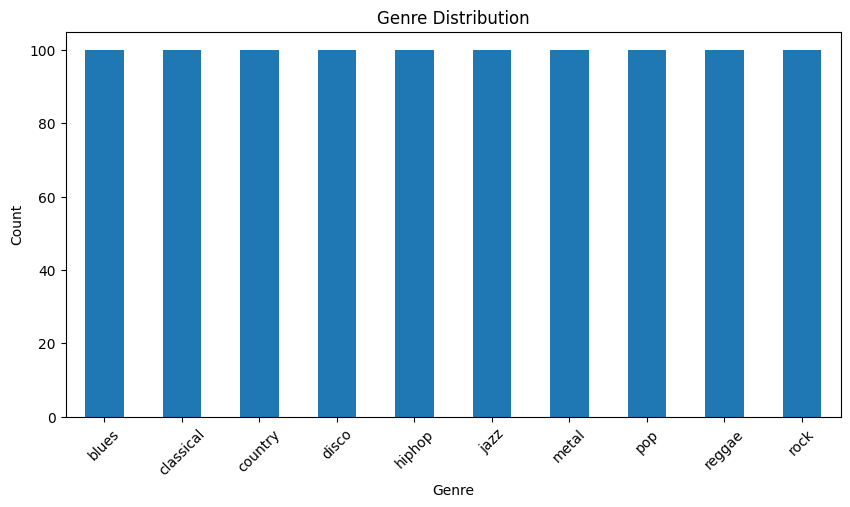

In [4]:
# class distribution
plt.figure(figsize=(10,5))
train_df['genre'].value_counts().plot(kind='bar')
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Observations
- Perfectly balanced
- 100 in each genre

## Raw Waveform

In [5]:
def get_audio_info(path):
    y, sr = librosa.load(path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    return sr, duration

sample_rows = train_df.sample(5, random_state=SEED)

for idx, row in sample_rows.iterrows():
    sr, dur = get_audio_info(row["drums"])
    print(f"{row['genre']} | SR: {sr} | Duration: {dur:.2f}s")

jazz | SR: 44100 | Duration: 30.01s
pop | SR: 44100 | Duration: 30.00s
pop | SR: 44100 | Duration: 30.00s
metal | SR: 44100 | Duration: 30.00s
hiphop | SR: 44100 | Duration: 30.01s


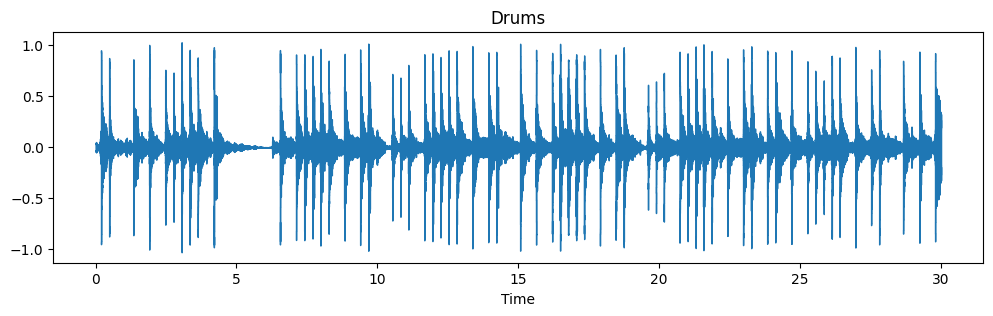

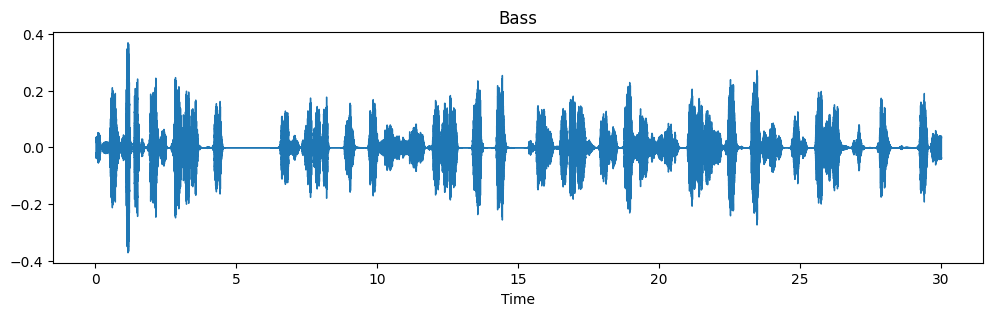

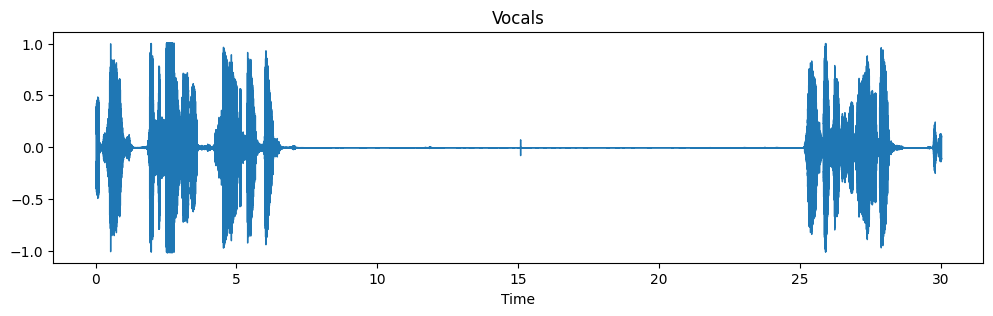

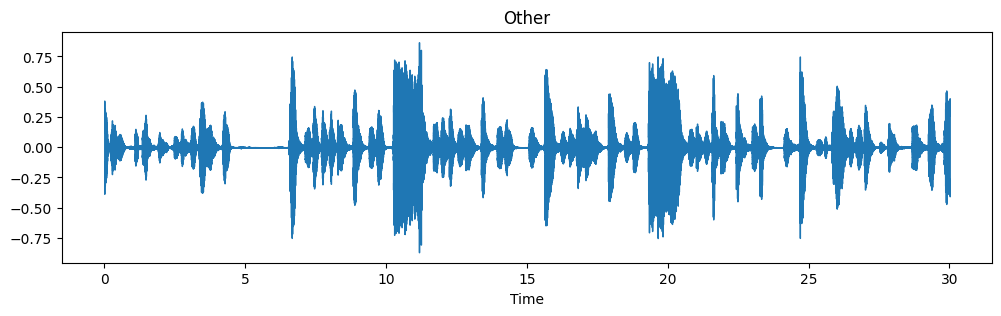

In [15]:
def plot_waveform(path, title="Waveform"):
    y, sr = librosa.load(path, sr=22050)
    
    plt.figure(figsize=(12,3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title)
    plt.show()

sample = train_df.sample(1).iloc[0]

plot_waveform(sample["drums"], "Drums")
plot_waveform(sample["bass"], "Bass")
plot_waveform(sample["vocals"], "Vocals")
plot_waveform(sample["other"], "Other")

Observations
- Drums
  - highly spiky
  - tempo + rhythm is the key genre signal
- Bass
  - Smooth, low freq dominant

- Vocals
  - Vocals are sometimes missing
  - not alone reliable

- Other
  - Mixed harmonic content
  - Carries background instruments

Bass --> low freq
Vocals --> mid freq
Drums --> Wide + transient
Other --> Full spectrum

## Mel-Spectrogram

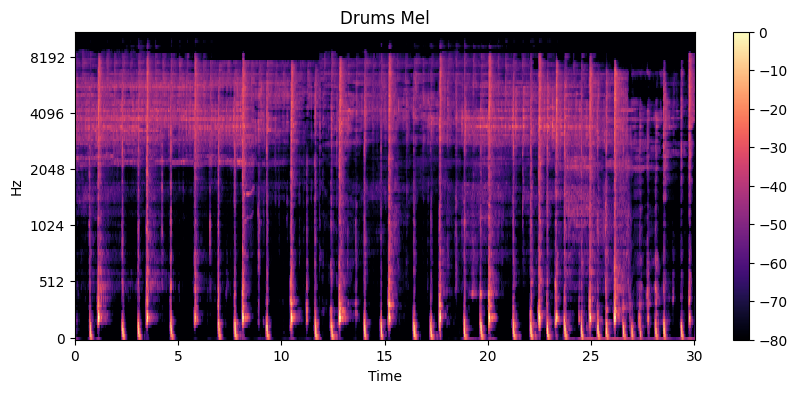

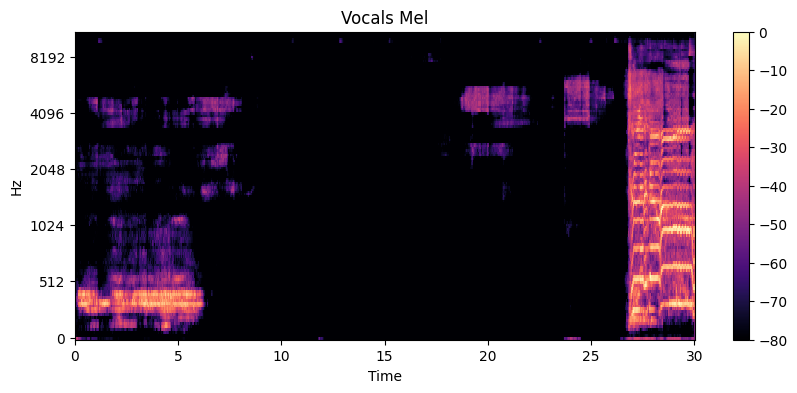

In [7]:
def plot_mel(path, title="Mel Spectrogram"):
    y, sr = librosa.load(path, sr=22050)
    
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    plt.figure(figsize=(10,4))
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar()
    plt.title(title)
    plt.show()

sample = train_df.sample(1).iloc[0]

plot_mel(sample["drums"], "Drums Mel")
plot_mel(sample["vocals"], "Vocals Mel")

Observation
- Drum mel --> vertical lines, wide frequency spread
- Vocals mel --> horizontal harmonic bands, sparse time regions

## Mashup Simulation

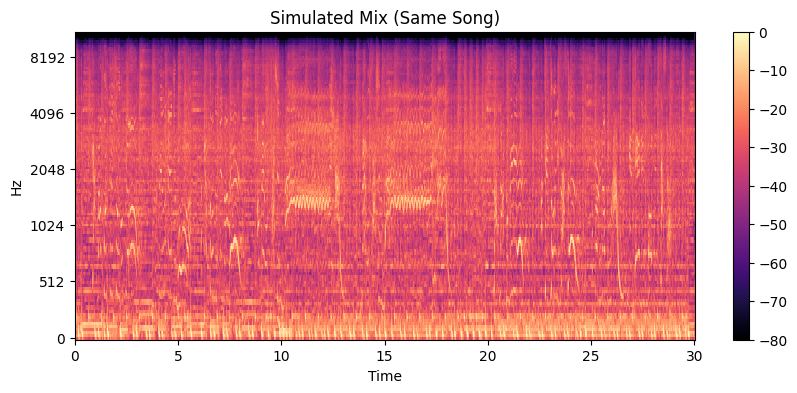

In [8]:
def load_audio(path, sr=22050):
    y, _ = librosa.load(path, sr=sr)
    return y

def mix_stems(row, sr=22050):
    y_drums = load_audio(row['drums'], sr)
    y_bass = load_audio(row['bass'], sr)
    y_vocals = load_audio(row['vocals'], sr)
    y_other = load_audio(row['other'], sr)

    # make same length
    min_len = min(len(y_drums), len(y_bass), len(y_vocals), len(y_other))

    y = (
        y_drums[:min_len] +
        y_bass[:min_len] +
        y_vocals[:min_len] +
        y_other[:min_len]
    )

    return y

sample = train_df.sample(1).iloc[0]
y_mix = mix_stems(sample)

mel = librosa.feature.melspectrogram(y=y_mix, sr=22050, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel')
plt.title("Simulated Mix (Same Song)")
plt.colorbar()
plt.show()

## Cross Song mashup simulation

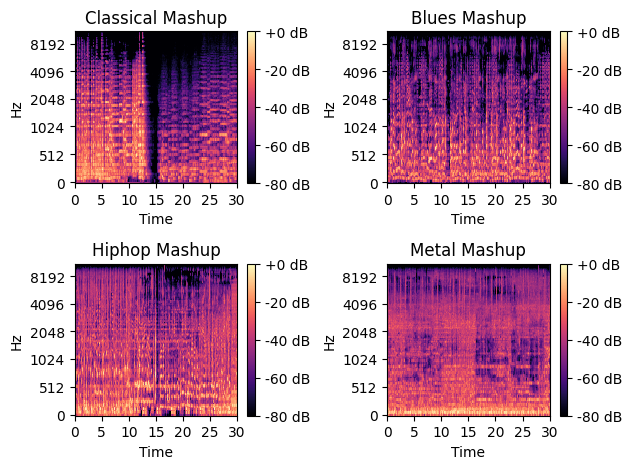

In [10]:
def cross_song_mix(df, genre, sr=22050):
    subset = df[df['genre'] == genre].sample(4)
    
    y_drums = load_audio(subset.iloc[0]["drums"], sr)
    y_bass = load_audio(subset.iloc[1]["bass"], sr)
    y_vocals = load_audio(subset.iloc[2]["vocals"], sr)
    y_other = load_audio(subset.iloc[3]["other"], sr)
    
    min_len = min(len(y_drums), len(y_bass), len(y_vocals), len(y_other))
    
    y = (
        y_drums[:min_len] +
        y_bass[:min_len] +
        y_vocals[:min_len] +
        y_other[:min_len]
    )
    
    return y

plot_genres = ['classical', 'blues', 'hiphop', 'metal']

for i, genre in enumerate(plot_genres, 1):
    y_cross = cross_song_mix(train_df, genre)
    
    mel = librosa.feature.melspectrogram(y=y_cross, sr=22050, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    plt.subplot(2, 2, i)
    librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel')
    plt.title(f"{genre.capitalize()} Mashup")
    plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

Observations
- Clean and smooth transitions
- Real mashups wont be this smooth and dense

## Noise Analysis

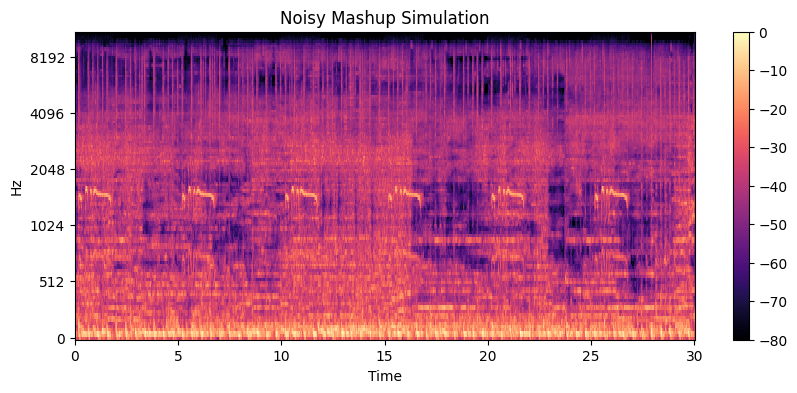

In [12]:
noise_files = os.listdir(NOISE_DIR)
noise_path = os.path.join(NOISE_DIR, random.choice(noise_files))

y_noise, sr = librosa.load(noise_path, sr=22050)

if len(y_noise) < len(y_cross):
    repeat_factor = int(np.ceil(len(y_cross) / len(y_noise)))
    y_noise = np.tile(y_noise, repeat_factor)

# match length
y_noise = y_noise[:len(y_cross)]

y_noisy = y_cross + 0.3 * y_noise

mel = librosa.feature.melspectrogram(y=y_noisy, sr=22050, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel')
plt.title("Noisy Mashup Simulation")
plt.colorbar()
plt.show()

Observation
- Noise fills high freq regions
- Blurs structure
- Appears in patches

## Test mashup visualization

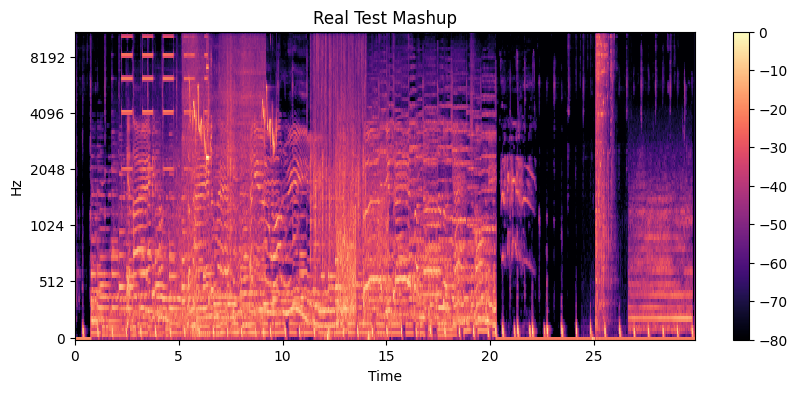

In [13]:
test_files = os.listdir(MASHUP_DIR)
test_path = os.path.join(MASHUP_DIR, random.choice(test_files))

plot_mel(test_path, "Real Test Mashup")

Observation
- noise is not uniform
- appears in patches
- sometimes dominates, sometimes subtle